In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from matplotlib.ticker import MultipleLocator
import warnings
warnings.filterwarnings("ignore")

In [2]:
def _base_dir() -> Path:
    try:
        return Path(__file__).resolve().parent.parent  # go up one level
    except NameError:
        return Path.cwd().resolve().parent             # go up one level

def _abs_path(p, base: Path) -> Path:
    p = Path(p).expanduser() if p else None
    return (base / p).resolve() if (p and not p.is_absolute()) else (p.resolve() if p else None)

def plot_latency_by_category(csv_path, model_name, win_size, stride, pdf_path):
    base = _base_dir()

    # Resolve absolute CSV path (fallback to default layout if csv_path not provided)
    csv_p = _abs_path(csv_path, base) or (base / "csv" / model_name / "small_dataset" /
                                         f"win{win_size}_stride{stride}_latancy_results.csv").resolve()
    if not csv_p.exists():
        raise FileNotFoundError(f"CSV not found: {csv_p}")

    # Resolve absolute output directory
    out_dir = _abs_path(pdf_path, base) or base
    out_dir.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(csv_p)
    exp_frames = df["sample_fps"] * df["window_seconds"]

    # Keep only full windows (drop tail fragments)
    dfv = df.loc[np.isclose(df["num_frames"], exp_frames, atol=1e-6)].copy()
    print("All rows:", len(df), "Valid rows:", len(dfv))
    print("Methods:", dfv["method_label"].unique())

    # Prefill latency in ms
    dfv["prefill_ms"] = (dfv["first_token_time"] - dfv["first_scheduled_time"]) * 1000.0

    # Mean prefill per (category, method)
    summary = (dfv.groupby(["category", "method_label"], as_index=False)["prefill_ms"].mean()
                 .pivot(index="category", columns="method_label", values="prefill_ms")
                 .sort_index())
    summary.loc["Avg"] = summary.mean(axis=0)

    methods = [m for m in ["w/ CacheBlend", "w/o CacheBlend"] if m in summary.columns]
    if not methods:
        raise ValueError(f"Expected method_label not found. Available: {list(summary.columns)}")

    x = np.arange(len(summary.index))
    w = 0.38 if len(methods) == 2 else 0.6
    fig, ax = plt.subplots(figsize=(5.2, 3.2), dpi=150)

    # Bars
    if len(methods) == 2:
        ax.bar(x - w/2, summary[methods[0]].values, w, label=methods[0], color=plt.cm.tab20b(3))
        ax.bar(x + w/2, summary[methods[1]].values, w, label=methods[1], color=plt.cm.tab20b(4))
    else:
        ax.bar(x, summary[methods[0]].values, w, label=methods[0], color=plt.cm.tab20b(0))

    ax.set_title("Prefill time by category (full windows) + Avg")
    ax.set_ylabel("prefill time (ms)")
    ax.set_xticks(x)
    ax.set_xticklabels(summary.index, rotation=45, ha="right")
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    # Dual-axis speedup (%): (w/o - w/) / (w/o) * 100
    if {"w/ CacheBlend", "w/o CacheBlend"}.issubset(summary.columns):
        base_ms, opt_ms = summary["w/o CacheBlend"].values, summary["w/ CacheBlend"].values
        sp = np.where(base_ms > 0, (base_ms - opt_ms) / base_ms * 100.0, np.nan)
        ax2 = ax.twinx()
        ax2.plot(x, sp, marker="o", linestyle="-", label="Speedup (w/ vs w/o)")
        ax2.set_ylabel("latency speedup (%)")
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, loc="best")
    else:
        ax.legend(loc="best")

    plt.tight_layout(pad=0.2)
    out_file = out_dir / f"{model_name}_win{win_size}_stride{stride}_prefill_by_category_with_avg_speedup.pdf"
    plt.savefig(out_file)
    print(f"Saved: {out_file}")
    return fig, ax

In [3]:
model_name = "InternVL3-14B"
model_name = "Qwen3-VL-32B-Instruct"
win_size = 40
stride = 20
pdf_path = "../pdfs" 
# plot_latency_by_category(
#     csv_path="",
#     model_name=model_name,
#     win_size=win_size,
#     stride=stride,
#     pdf_path=pdf_path,
# )

In [4]:
def plot_latency_changes_by_reused_tokens(csv_path, model_name, win_size, pdf_path):
    df = pd.read_csv(csv_path)

    base = _base_dir()
    out_dir = _abs_path(pdf_path, base) or base
    out_dir.mkdir(parents=True, exist_ok=True)

    fig, ax0 = plt.subplots(figsize=(3, 2), dpi=150)

    df = df[(df["window_seconds"] == win_size) & (df["method"] == "w_cacheblend")].copy()
    df["expected_num_frames"] = df["sample_fps"] * df["window_seconds"]
    df = df[np.isclose(df["num_frames"], df["expected_num_frames"], atol=1e-6)].copy()

    stride_ratios = sorted(df["stride_ratio"].unique())
    categorys = sorted(df["category"].unique())

    categorys = ["fighting"]
    df = df[df["category"].isin(categorys)]

    latency_means = []
    for ratio in stride_ratios:
        d = df[df["stride_ratio"] == ratio]
        ttft = d["first_token_time"] - d["first_scheduled_time"]
        latency_means.append(ttft.mean())

    ax0.plot(stride_ratios, latency_means, marker="o", linestyle="-")
    ax0.set_xlabel("Stride ratios")
    ax0.set_ylabel("TTFT (s)")
    ax0.grid(axis="y", linestyle=":", alpha=0.4)

    df["ground_truth"] = df["label"].apply(lambda x: "No" if x == "normal" else "Yes")

    group_cols = [
        "video_path",
        "category",
        "window_seconds",
        "sample_fps",
        "stride_ratio",
        "method",
    ]

    # def aggregate_video_level(g):
    #     gt = g["ground_truth"].iloc[0]
    #     if gt == "Yes":
    #         pred = "Yes" if (g["est"] == "Yes").any() else "No"
    #     else:
    #         pred = "No" if (g["est"] == "No").all() else "Yes"
    #     return pd.Series({"ground_truth": gt, "est": pred})

    # df = (
    #     df.groupby(group_cols, as_index=False)
    #       .apply(aggregate_video_level)
    #       .reset_index(drop=True)
    # )

    def f1_of_df(d):
        tp = ((d["est"] == "Yes") & (d["ground_truth"] == "Yes")).sum()
        fp = ((d["est"] == "Yes") & (d["ground_truth"] == "No")).sum()
        fn = ((d["est"] == "No") & (d["ground_truth"] == "Yes")).sum()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    avg_f1_per_ratio = []
    for ratio in stride_ratios:
        f1_list = []
        for category in categorys:
            d = df[(df["stride_ratio"] == ratio) & (df["category"] == category)]
            if not d.empty:
                if f1_of_df(d) <= 0:
                    continue
                f1_list.append(f1_of_df(d))
        avg_f1_per_ratio.append(float(np.mean(f1_list)) if len(f1_list) > 0 else 0.0)

    print("Stride Ratios:", stride_ratios)
    print("Latency Means:", latency_means)
    print("Avg F1 per Ratio:", avg_f1_per_ratio)
    ax1 = ax0.twinx()
    ax1.plot(stride_ratios, avg_f1_per_ratio, marker="s", linestyle="--", label="F1 Score", color=plt.cm.tab20b(2))
    ax1.set_ylabel("F1 Score")
    ax1.legend(loc="best", frameon=False)

    plt.tight_layout(pad=0.0)
    out_file = out_dir / f"{model_name}_win{win_size}_performance_vs_stride_ratios.pdf"
    plt.savefig(out_file)
    print(f"Saved: {out_file}")

    return fig, ax0

In [5]:
def _trimmed_mean(x: pd.Series) -> float:
    """Drop min & max then mean; fallback to mean if <3 points."""
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x) >= 3:
        x = x.sort_values().iloc[1:-1]
    return float(x.mean()) if len(x) else 0.0


def _f1_of_df(d: pd.DataFrame) -> float:
    tp = ((d["est"] == "Yes") & (d["ground_truth"] == "Yes")).sum()
    fp = ((d["est"] == "Yes") & (d["ground_truth"] == "No")).sum()
    fn = ((d["est"] == "No") & (d["ground_truth"] == "Yes")).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return float(2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0


def save_points_latency_f1_vs_stride_ratio(
    raw_csv_path: str,
    points_csv_path: str,
    win_size: int,
    model_name: str,
    categories=None,
    method: str = "w_cacheblend",
):
    """
    Stage 1: read raw csv -> compute plot points -> save to points_csv_path.
    Output schema (one row per stride_ratio):
      model_name,window_seconds,method,categories,stride_ratio,ttft_mean_s,f1_mean
    """
    df = pd.read_csv(raw_csv_path)

    df = df[(df["window_seconds"] == win_size) & (df["method"] == method)].copy()
    df["expected_num_frames"] = df["sample_fps"] * df["window_seconds"]
    df = df[np.isclose(df["num_frames"], df["expected_num_frames"], atol=1e-6)].copy()

    if categories is None:
        categories = sorted(df["category"].unique())
    else:
        categories = list(categories)
    df = df[df["category"].isin(categories)].copy()

    if df.empty:
        raise ValueError("Filtered dataframe is empty. Check win_size/method/categories filters.")

    stride_ratios = sorted(df["stride_ratio"].unique())

    # ground truth + est label normalization
    df["ground_truth"] = df["label"].apply(lambda x: "No" if x == "normal" else "Yes")

    rows = []
    for ratio in stride_ratios:
        d_ratio = df[df["stride_ratio"] == ratio].copy()
        if d_ratio.empty:
            continue

        # TTFT = first_token_time - first_scheduled_time
        ttft = d_ratio["first_token_time"] - d_ratio["first_scheduled_time"]
        ttft_mean = _trimmed_mean(ttft)  # or use ttft.mean() if you don't want trimming

        # F1 averaged across categories (skip <=0 like your original)
        f1_list = []
        for cat in categories:
            d = d_ratio[d_ratio["category"] == cat]
            if d.empty:
                continue
            f1 = _f1_of_df(d)
            if f1 <= 0:
                continue
            f1_list.append(f1)
        f1_mean = float(np.mean(f1_list)) if f1_list else 0.0

        rows.append(
            {
                "model_name": model_name,
                "window_seconds": win_size,
                "method": method,
                "categories": ",".join(categories),
                "stride_ratio": float(ratio),
                "ttft_mean_s": float(ttft_mean),
                "f1_mean": float(f1_mean),
            }
        )

    points_df = pd.DataFrame(rows).sort_values("stride_ratio").reset_index(drop=True)

    points_path = Path(points_csv_path)
    points_path.parent.mkdir(parents=True, exist_ok=True)
    points_df.to_csv(points_path, index=False)
    print(f"Saved points CSV: {points_path} (rows={len(points_df)})")

    return points_df


def plot_latency_f1_from_points_csv(
    points_csv_path: str,
    pdf_path: str,
    model_name: str,
    win_size: int,
):
    df = pd.read_csv(points_csv_path)
    df = df[
        (df["model_name"] == model_name)
        & (df["window_seconds"] == win_size)
    ]
    if df.empty:
        raise ValueError("No matching rows in points CSV.")

    x = df["stride_ratio"].to_numpy()
    ttft = df["ttft_mean_s"].to_numpy()
    f1 = df["f1_mean"].to_numpy()

    out_path = Path(pdf_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    fig, ax0 = plt.subplots(figsize=(3, 2), dpi=150)

    c_ttft = plt.cm.tab20b(0/5)
    c_f1 = plt.cm.tab20b(1/5)

    ax0.plot(x, ttft, "-o", color=c_ttft, label="TTFT")
    ax0.set_xlabel("Stride Ratio")
    ax0.set_ylabel("TTFT (s)", color=c_ttft)
    ax0.tick_params(axis="y", colors=c_ttft)
    ax0.grid(axis="y", linestyle=":", alpha=0.4)

    ax1 = ax0.twinx()
    ax1.plot(x, f1, "--s", color=c_f1, label="F1 Score")
    ax1.set_ylabel("F1 Score", color=c_f1)
    ax1.tick_params(axis="y", colors=c_f1)
    ax0.xaxis.set_major_locator(MultipleLocator(0.1))
    ax0.tick_params(axis="x", labelrotation=20)

    lines = ax0.get_lines() + ax1.get_lines()
    # ax0.legend(lines, [l.get_label() for l in lines], frameon=False)

    plt.tight_layout(pad=0.0)
    plt.savefig(out_path)
    return fig, ax0

def plot_latency_f1_from_points_csv_reused_tokens(
    points_csv_path: str,
    pdf_path: str,
    model_name: str,
    win_size: int,
):
    df = pd.read_csv(points_csv_path)
    df = df[
        (df["model_name"] == model_name)
        & (df["window_seconds"] == win_size)
    ]
    if df.empty:
        raise ValueError("No matching rows in points CSV.")

    # x = df["stride_ratio"].to_numpy()
    df["reused_tokens"] = (1-df["stride_ratio"]) * win_size * 2 * 260 * (1-0.15) # convert to reused tokens
    df = df.sort_values("reused_tokens").copy()
    x = df["reused_tokens"].to_numpy()
    ttft = df["ttft_mean_s"].to_numpy()
    f1 = df["f1_mean"].to_numpy()

    out_path = Path(pdf_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    fig, ax0 = plt.subplots(figsize=(3, 2), dpi=150)

    c_ttft = plt.cm.tab20b(0/5)
    c_f1 = plt.cm.tab20b(1/5)

    ax0.plot(x, ttft, "-o", color=c_ttft, label="TTFT")
    ax0.set_xlabel("Reused Tokens")
    ax0.set_ylabel("TTFT (s)", color=c_ttft)
    ax0.tick_params(axis="y", colors=c_ttft)
    ax0.grid(axis="y", linestyle=":", alpha=0.4)

    ax1 = ax0.twinx()
    ax1.plot(x, f1, "--s", color=c_f1, label="F1 Score")
    ax1.set_ylabel("F1 Score", color=c_f1)
    ax1.tick_params(axis="y", colors=c_f1)
    ax0.xaxis.set_major_locator(MultipleLocator(4000))
    ax0.tick_params(axis="x", labelrotation=20)

    lines = ax0.get_lines() + ax1.get_lines()
    # ax0.legend(lines, [l.get_label() for l in lines], frameon=False)

    plt.tight_layout(pad=0.0)
    plt.savefig(out_path)
    return fig, ax0

def plot_latency_changes_by_reused_tokens(
    raw_csv_path: str,
    model_name: str,
    win_size: int,
    pdf_path: str,
    points_csv_path: str = None,
    categories=("fighting",),
    method: str = "w_cacheblend",
):
    """
    Wrapper: compute points -> save -> reload -> plot.
    """
    if points_csv_path is None:
        out_dir = Path(os.path.dirname(pdf_path) or ".")
        points_csv_path = str(out_dir / f"{model_name}_win{win_size}_points_vs_stride_ratio.csv")

    # save_points_latency_f1_vs_stride_ratio(
    #     raw_csv_path=raw_csv_path,
    #     points_csv_path=points_csv_path,
    #     win_size=win_size,
    #     model_name=model_name,
    #     categories=categories,
    #     method=method,
    # )

    return plot_latency_f1_from_points_csv_reused_tokens(
        points_csv_path=points_csv_path,
        pdf_path=pdf_path,
        model_name=model_name,
        win_size=win_size,
    )


(<Figure size 450x300 with 2 Axes>,
 <Axes: xlabel='Reused Tokens', ylabel='TTFT (s)'>)

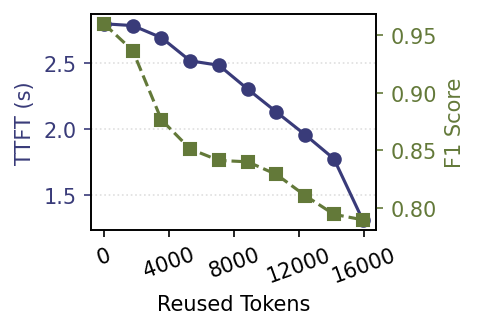

In [6]:
model_name = "InternVL3-14B"
csv_path = _abs_path("", _base_dir()) or (_base_dir() / "csv" / model_name / "small_dataset" /
                                         f"win40_stride10-100_all_metrics_results.csv").resolve()
# plot_latency_changes_by_reused_tokens(
#     csv_path=csv_path,
#     model_name=model_name,
#     win_size=win_size,
#     pdf_path=pdf_path,
# )
pdf_out = "../pdfs/InternVL3-14B_win40_performance_vs_stride_ratios_fighting.pdf"
plot_latency_changes_by_reused_tokens(
    raw_csv_path=csv_path,
    model_name="InternVL3-14B",
    win_size=40,
    pdf_path=pdf_out,
    categories=("fighting",),   
)

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_latency_changes_by_recompute_ratios(
    csv_path: str,
    model_name: str,
    win_size: int,
    pdf_path: str,
    method: str | None = None,
    categories: list[str] | None = None,
    rotate_xticks: bool = False,
):
    df = pd.read_csv(csv_path)

    base = _base_dir()
    out_dir = _abs_path(pdf_path, base) or base
    out_dir.mkdir(parents=True, exist_ok=True)
    print("Output directory:", out_dir)

    df = df[df["window_seconds"] == win_size].copy()
    df["expected_num_frames"] = df["sample_fps"] * df["window_seconds"]
    df = df[np.isclose(df["num_frames"], df["expected_num_frames"], atol=1e-6)].copy()
    if method is not None and "method" in df.columns:
        df = df[df["method"] == method].copy()
    print("categorys available:", df["category"].unique())    
    if categories is not None:
        df = df[df["category"].isin(categories)].copy()

    if df.empty:
        raise ValueError("Filtered dataframe is empty. Check win_size/method/categories/num_frames filters.")

    recompute_ratios = sorted(df["recompute_ratio"].unique())
    categorys = sorted(df["category"].unique())

    # ---------- TTFT per ratio (trimmed mean: drop min & max if >=3) ----------
    latency_means = []
    for r in recompute_ratios:
        d = df[df["recompute_ratio"] == r]
        ttft = (d["first_token_time"] - d["first_scheduled_time"]).dropna()
        if len(ttft) >= 3:
            ttft = ttft.sort_values().iloc[1:-1]
        latency_means.append(float(ttft.mean()) if len(ttft) else 0.0)

    # ---------- Video-level aggregation for accuracy ----------
    df["ground_truth"] = df["label"].apply(lambda x: "No" if x == "normal" else "Yes")

    group_cols = ["video_path", "category", "window_seconds", "sample_fps", "recompute_ratio"]
    if "method" in df.columns:
        group_cols.append("method")

    def aggregate_video_level(g: pd.DataFrame) -> pd.Series:
        gt = g["ground_truth"].iloc[0]
        if gt == "Yes":
            pred = "Yes" if (g["est"] == "Yes").any() else "No"
        else:
            pred = "No" if (g["est"] == "No").all() else "Yes"
        return pd.Series({"ground_truth": gt, "est": pred})

    video_df = (
        df.groupby(group_cols, dropna=False, sort=False)
          .apply(aggregate_video_level)
          .reset_index()
    )

    def f1_from_counts(tp: int, fp: int, fn: int) -> float:
        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        return float(2 * p * r / (p + r)) if (p + r) > 0 else 0.0

    def f1_of_df(d: pd.DataFrame) -> float:
        tp = int(((d["est"] == "Yes") & (d["ground_truth"] == "Yes")).sum())
        fp = int(((d["est"] == "Yes") & (d["ground_truth"] == "No")).sum())
        fn = int(((d["est"] == "No") & (d["ground_truth"] == "Yes")).sum())
        return f1_from_counts(tp, fp, fn)

    # ---------- Macro-F1 (your requirement) and Micro-F1 (for debugging) ----------
    macro_f1_per_ratio = []
    micro_f1_per_ratio = []

    for r in recompute_ratios:
        d_r = video_df[video_df["recompute_ratio"] == r]

        # micro-F1 across all categories at this ratio
        micro_f1_per_ratio.append(f1_of_df(d_r) if not d_r.empty else 0.0)

        # macro-F1: average of per-category F1 (only categories present in d_r)
        f1_list = []
        for cat in categorys:
            d_c = d_r[d_r["category"] == cat]
            if d_c.empty:
                continue
            print(f"Ratio={r}, Category={cat}, Samples={len(d_c)}, F1={f1_of_df(d_c):.4f}")
            f1_list.append(f1_of_df(d_c))
        macro_f1_per_ratio.append(float(np.mean(f1_list)) if f1_list else 0.0)

    # ---------- Plot (style aligned with your requirements) ----------
    fig, ax0 = plt.subplots(figsize=(3, 2), dpi=150)

    c_ttft = plt.cm.tab20b(0/5)
    c_f1 = plt.cm.tab20b(1/5)

    ax0.plot(recompute_ratios, latency_means, "-o", color=c_ttft)
    ax0.set_xlabel("Recompute Ratio")
    ax0.set_ylabel("TTFT (s)", color=c_ttft)
    ax0.tick_params(axis="y", colors=c_ttft)
    ax0.grid(axis="y", linestyle=":", alpha=0.4)

    if rotate_xticks:
        ax0.tick_params(axis="x", labelrotation=45)
        plt.setp(ax0.get_xticklabels(), ha="right", rotation_mode="anchor")

    ax1 = ax0.twinx()
    ax1.plot(recompute_ratios, macro_f1_per_ratio, "--s", color=c_f1)
    ax1.set_ylabel("F1 Score", color=c_f1)
    ax1.tick_params(axis="y", colors=c_f1)
    plt.title("categories: " + ", ".join(categories))
    plt.tight_layout(pad=0.0)
    out_file = out_dir / f"{model_name}_win{win_size}_performance_vs_recompute_ratios_all_layers.pdf"
    print(f"Saved: {out_file}")
    plt.savefig(out_file)
    return fig, ax0, {
        "recompute_ratios": recompute_ratios,
        "ttft": latency_means,
        "macro_f1": macro_f1_per_ratio,
        "micro_f1": micro_f1_per_ratio,
        "categories": categorys,
        "out_file": str(out_file),
    }


Output directory: /root/workspace/lmcache_multimodal/scripts_test_video/pdfs
categorys available: ['abuse' 'arson' 'fighting']
Ratio=0.1, Category=abuse, Samples=40, F1=0.8571
Ratio=0.1, Category=fighting, Samples=40, F1=0.9756
Ratio=0.2, Category=abuse, Samples=40, F1=0.8571
Ratio=0.2, Category=fighting, Samples=40, F1=0.9756
Ratio=0.3, Category=abuse, Samples=40, F1=0.8571
Ratio=0.3, Category=fighting, Samples=40, F1=0.9756
Ratio=0.4, Category=abuse, Samples=40, F1=0.8571
Ratio=0.4, Category=fighting, Samples=40, F1=0.9756
Ratio=0.5, Category=abuse, Samples=40, F1=0.8571
Ratio=0.5, Category=fighting, Samples=40, F1=0.9756
Ratio=0.6, Category=abuse, Samples=40, F1=0.8571
Ratio=0.6, Category=fighting, Samples=40, F1=0.9756
Ratio=0.7, Category=abuse, Samples=40, F1=0.8571
Ratio=0.7, Category=fighting, Samples=40, F1=0.9756
Saved: /root/workspace/lmcache_multimodal/scripts_test_video/pdfs/InternVL3-14B_win40_performance_vs_recompute_ratios_all_layers.pdf


(<Figure size 450x300 with 2 Axes>,
 <Axes: xlabel='Recompute Ratio', ylabel='TTFT (s)'>,
 {'recompute_ratios': [np.float64(0.1),
   np.float64(0.2),
   np.float64(0.3),
   np.float64(0.4),
   np.float64(0.5),
   np.float64(0.6),
   np.float64(0.7)],
  'ttft': [2.4515168536874583,
   2.5301485294686223,
   2.451852664463502,
   2.445554257783675,
   2.4736154895079765,
   2.44725693706283,
   2.4497941889260946],
  'macro_f1': [0.9163763066202091,
   0.9163763066202091,
   0.9163763066202091,
   0.9163763066202091,
   0.9163763066202091,
   0.9163763066202091,
   0.9163763066202091],
  'micro_f1': [0.9156626506024096,
   0.9156626506024096,
   0.9156626506024096,
   0.9156626506024096,
   0.9156626506024096,
   0.9156626506024096,
   0.9156626506024096],
  'categories': ['abuse', 'fighting'],
  'out_file': '/root/workspace/lmcache_multimodal/scripts_test_video/pdfs/InternVL3-14B_win40_performance_vs_recompute_ratios_all_layers.pdf'})

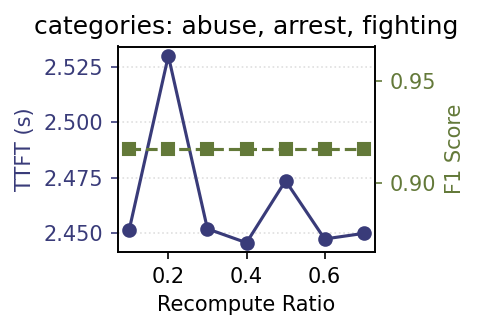

In [8]:
model_name = "InternVL3-14B"
csv_path = _abs_path("", _base_dir()) or (_base_dir() / "csv" / model_name / "small_dataset" /
                                         f"yulin_recompute_ratios_all_layers.csv").resolve()
# csv_path = _abs_path("", _base_dir()) or (_base_dir() / "csv" / model_name / "small_dataset" /
                                        #  f"win40_stride20_reuse_tokens_all_metrics_results.csv").resolve()
plot_latency_changes_by_recompute_ratios(
    csv_path=csv_path,
    model_name=model_name,
    win_size=40,
    pdf_path=pdf_path,
    categories=['abuse', 'arrest', 'fighting'],
)